In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [4]:
# !pip install wandb

In [5]:
# !wandb login

In [6]:
import wandb

In [7]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Current Device:", torch.cuda.current_device())
else:
    print("GPU not detected")

CUDA available: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
Current Device: 0


In [8]:
train_df= pd.read_csv("../data/train.csv")
test_df= pd.read_csv("../data/test.csv")

In [9]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [10]:
train_df.iloc[2,1]

'Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.'

## EDA

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# ********************** basic statistics ****************
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(f"\nMissing values in training dataset:\n{train_df.isna().sum()}")
print(f"\nMissing values in testing dataset:\n{test_df.isna().sum()}")


# ******************** ANSWER DISTRIBUTION *******************
# Very important for understanding bias
train_answer_dist= train_df['answer'].value_counts()
print(f"\nTraining Dataset Answer Distribution:")
print(train_answer_dist)
print(f"\nPercentages:\n{round(train_answer_dist/len(train_df)*100,1)}")


Train dataset shape: (2000, 8)
Test dataset shape: (500, 7)

Missing values in training dataset:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in testing dataset:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Training Dataset Answer Distribution:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Percentages:
answer
B    24.5
C    23.0
A    18.4
D    17.9
E    16.2
Name: count, dtype: float64


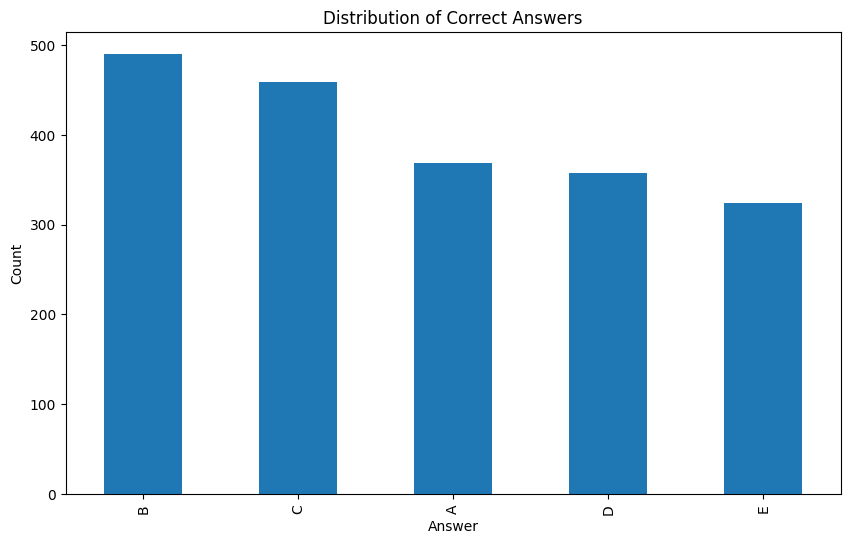

In [13]:
#******************** Plot Answer distribution *************
plt.figure(figsize=(10, 6))
train_answer_dist.plot(kind= 'bar')
plt.title('Distribution of Correct Answers')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.show()

In [14]:
# ************************** Text Length Analysis *********************
# Understanding question and option lengths
train_df['prompt_length']= train_df['prompt'].str.len()
train_df['option_A_len']= train_df['A'].str.len()
train_df['option_B_len']= train_df['B'].str.len()
train_df['option_C_len']= train_df['C'].str.len()
train_df['option_D_len']= train_df['D'].str.len()
train_df['option_E_len']= train_df['E'].str.len()

print(f"\nText Length Statistic:")
print(f"\n{train_df[['prompt_length', 'option_A_len', 'option_B_len', 'option_C_len', 'option_D_len', 'option_E_len']].describe()}")


Text Length Statistic:

       prompt_length  option_A_len  ...  option_D_len  option_E_len
count    2000.000000   2000.000000  ...    2000.00000   2000.000000
mean      117.669500    164.091500  ...     162.56350    164.230000
std        44.408674    105.677145  ...     104.11657    107.777712
min        19.000000      1.000000  ...       1.00000      2.000000
25%        87.750000     86.000000  ...      91.00000     84.000000
50%       111.000000    143.000000  ...     141.00000    144.000000
75%       141.000000    234.000000  ...     231.00000    224.000000
max       337.000000    472.000000  ...     450.00000    587.000000

[8 rows x 6 columns]


In [15]:
#************************* Question Patterns ***************************
# are there common question prefixs?
prefixs= train_df['prompt'].str[:50].value_counts().head(10)
print(f"Common questions prefixes:\n {prefixs}")

# *********************** Option Similarity **************************
# Check if options are very similar

def cal_similarity(row):
    options= [row['A'],row['B'], row['C'], row['D'], row['E']]
    prefixes= [ops[:30] for ops in options]
    return len(set(prefixes))

train_df['unique_prefixe_options']= train_df.apply(cal_similarity, axis=1)

print(f"\nQuestions with very similar options (unique_prefixs <3):")
print(f"{(train_df['unique_prefixe_options']<3).sum()}")

Common questions prefixes:
 prompt
Identify the correct statement: What is the relati    22
Choose the correct answer: Which of the following     21
Pick the best possible answer: What is the reason     19
Identify the correct statement: What is the signif    18
Pick the best possible answer: What is the relatio    18
Determine the correct option: What is the relation    18
Select the most accurate option: What is the reaso    18
Which of the following is correct? What is the rel    17
Select the most accurate option: What is the relat    17
Which of the following is correct? What is the rea    16
Name: count, dtype: int64

Questions with very similar options (unique_prefixs <3):
1078


### 1078 out of 2000 (54%) have very similar option prefixes ; Means
* Simple keyword matching will FAIL 
* Need semantic understanding, not just text overlap \n
* This is why pretrained transformers (Model 2) will shine \n

In [16]:
# ******************************** Correct answer position ***********************
# Is correct answer more likely in longer/shorter options?

for ans in ["A", "B", "C", "D", "E"]:
    subset= train_df[train_df['answer']==ans]
    ans_desc_stat= subset[f"option_{ans}_len"].describe()
    print(f"\nStatistic for correct option {ans}:\n{ans_desc_stat}")



Statistic for correct option A:
count    369.000000
mean     181.363144
std      104.731143
min        3.000000
25%      112.000000
50%      191.000000
75%      240.000000
max      409.000000
Name: option_A_len, dtype: float64

Statistic for correct option B:
count    490.000000
mean     171.183673
std      126.513863
min        2.000000
25%       77.000000
50%      144.000000
75%      251.000000
max      545.000000
Name: option_B_len, dtype: float64

Statistic for correct option C:
count    459.000000
mean     182.346405
std       99.116643
min        9.000000
25%      104.000000
50%      189.000000
75%      254.000000
max      395.000000
Name: option_C_len, dtype: float64

Statistic for correct option D:
count    358.000000
mean     180.349162
std       78.417066
min       24.000000
25%      118.250000
50%      183.000000
75%      235.000000
max      403.000000
Name: option_D_len, dtype: float64

Statistic for correct option E:
count    324.000000
mean     199.669753
std      136.51

Key Questions to Answer:

1. Is there answer bias? (Are B or C more common than E?) -> No
2. Are correct answers longer/shorter than incorrect ones?
3. Do questions follow patterns? (e.g., "Pick the best possible answer:") -> yes
4. How similar are the options? (Will text matching work or need deep understanding?)

## Data Preprocessing

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow import keras

In [18]:
# ********************* investigate duplicates ****************
# 1. Find exact duplicates (question/prompt + all options same)

duplicate_mask= train_df[['prompt', "A", "B", "C", 'D', 'E']].duplicated(keep=False) # keep=False ; do NOT keep any copy special If a duplicate group exists: mark ALL members True.
duplicates_df= train_df[duplicate_mask]

print(f"Total rows involved in duplicates: {len(duplicates_df)}")

# 2. Check if duplicates have SAME or DIFFERENT answers
duplicate_groups= train_df[duplicate_mask].groupby(['prompt', "A", "B", "C", 'D', 'E']) # this groupby return groupby object ; like list of two things first that unique (prompt, a, b, c, d, e) select cols (called as 'name') and 'group' dataframe where exact those rows come which have these same selected columns(prompt, 'a'...)

print("\n*** Critical: Do duplicates agree on answer? ****")

for name, group in list(duplicate_groups): 
    print(f"\nQuestion: {name[0][:80]}..")
    print(f"Appears {len(group)} times")
    print(f"Answers: {group['answer'].values}")

    if group['answer'].nunique()>1:
        print("Warning: Same question, different answer!")

# 3. find same prompts with different options
prompt_duplicates= train_df[train_df['prompt'].duplicated(keep=False)]
prompt_group= prompt_duplicates.groupby('prompt')

for prompt, group in list(prompt_group):
    if len(group[['A', "B", "C", "D", "E"]].drop_duplicates())>1:
        print(f"\nPrompt: {prompt[:80]}...")
        print(f"Appears with {len(group)} different option sets")
        # print(group[['A', "B", "C", "D", "E", "answer"]])


Total rows involved in duplicates: 344

*** Critical: Do duplicates agree on answer? ****

Question: Choose the correct answer: What are permutation-inversion groups?..
Appears 3 times
Answers: ['E' 'E' 'E']

Question: Choose the correct answer: What are permutation-inversion groups? based on the g..
Appears 2 times
Answers: ['E' 'E']

Question: Choose the correct answer: What are the four qualitative levels of crystallinity..
Appears 3 times
Answers: ['B' 'B' 'B']

Question: Choose the correct answer: What is Lorentz symmetry or Lorentz invariance in rel..
Appears 2 times
Answers: ['E' 'E']

Question: Choose the correct answer: What is a pycnometer?..
Appears 2 times
Answers: ['D' 'D']

Question: Choose the correct answer: What is magnetic susceptibility? based on the given c..
Appears 2 times
Answers: ['B' 'B']

Question: Choose the correct answer: What is the American Petroleum Institute (API) gravit..
Appears 2 times
Answers: ['A' 'A']

Question: Choose the correct answer: What is 

* Pros
- 2000 training samples vs 1817 (keep 183 extra samples!)
- Test set probably has duplicates too -> memorizing is VALUABLE
- Model learns robustness (same Q, slightly different context)
- More data = better generalization
- No data quality issues to worry about

* cons
- Might overfit to specific questions (minor risk)
- Slightly redundant training signal

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

def clean_prompt(prompt):
    # remove standardized prefixes
    if (':' in prompt) or ('?' in prompt):
        if ':' in prompt:
            sep_prompt= prompt.strip().split(':')
            return ':'.join(sep_prompt[1:]).strip()
        if '?' in prompt:
            sep_prompt= prompt.strip().split('?')
            return '?'.join(sep_prompt).strip()
    return prompt

# Reduces noise in TF-IDF features
# Shorter sequences for BERT (fits more context in 512 tokens)
# Models focus on actual question content

train_df['prompt']= train_df['prompt'].apply(clean_prompt)
test_df['prompt']= test_df['prompt'].apply(clean_prompt)

# ************************* Train/Validate split *********************
# train_data, val_data= train_test_split(train_df, test_size= 0.2, random_state=42, stratify= train_df['answer']) # keep answer distribution
train_df['prompt_group']= train_df['prompt'].factorize()[0]
splitter= GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in splitter.split(train_df, groups= train_df['prompt_group']):
    train_data= train_df.iloc[train_idx].reset_index(drop=True)
    val_data= train_df.iloc[val_idx].reset_index(drop=True)
    break # only one split

# verify no leakage
train_prompts= set(train_data['prompt'].unique())
val_prompts= set(val_data['prompt'].unique())
overlap= train_prompts & val_prompts
print(f"Overlapping prompts: {len(overlap)} (should be 0!)")



print(f"Train: {len(train_data)}, validation: {len(val_data)}")


# def clean_text(text):
#     # Usually not needed for modern models, but consider:
#     text = text.strip()
#     # Don't lowercase if using pretrained models (they expect proper case)
#     return text

# ***************************** Label Encoder ***********************
label_map= {"A":0, "B":1, "C":2, "D":3, "E":4}
train_data['label']= train_data['answer'].map(label_map)
val_data['label']= val_data['answer'].map(label_map)


# # **************************** combine question and options *******************
# Combine question + all options into one text

def ceate_text_feature(row):
    return f"{row['prompt']} [SEP] A: {row['A']}, B: {row['B']}, C: {row['C']}, D: {row['D']}, E: {row['E']}"

train_data['combined_text']= train_data.apply(ceate_text_feature, axis=1)
val_data['combined_text']= val_data.apply(ceate_text_feature, axis=1)
test_df['combined_text']= test_df.apply(ceate_text_feature, axis=1)

Overlapping prompts: 0 (should be 0!)
Train: 1576, validation: 424


In [20]:
# # ****************************** if we want to do cross validation (n_splits>1) *********************************
# train_df['prompt_group']= train_df['prompt'].factorize()[0]

# ## ************** K-fold validation **************************
# n_splits=3
# splitter= GroupShuffleSplit(n_splits=n_splits,test_size=0.2, random_state=42)

# for fold, (train_idx, val_idx) in enumerate(splitter.split(train_df, groups= train_df['prompt_group']),1):
#     print(f"{'='*50}")
#     print(f"FOLD {fold}/{n_splits}")
#     print(f"{'='*50}")

#     train_data= train_df.iloc[train_idx].reset_index(drop=True)
#     val_data= train_df.iloc[val_idx].reset_index(drop=True)

#     print(f"Train : {len(train_data)} samples")
#     print(f"Val: {len(val_data)} samples")

#     # verify leakage
#     overlap= set(train_data['prompt']) & set(val_data['prompt'])
#     assert len(overlap)==0, f"Leakage detected! {len(overlap)} overlapping prompts"


#     # ***************************** Label Encoder ***********************
#     label_map= {"A":0, "B":1, "C":2, "D":3, "E":4}
#     train_data['label']= train_data['answer'].map(label_map)
#     val_data['label']= val_data['answer'].map(label_map)

#     # **************************** combine question and options *******************
#     # Combine question + all options into one text
#     train_data['combined_text']= train_data.apply(ceate_text_feature, axis=1)
#     val_data['combined_text']= val_data.apply(ceate_text_feature, axis=1)


#     #************************* Train Model1 *********************
    
    
    


In [21]:
############### weight and bais initiaze for first model ##############
# Start a new wandb run to track this script.
run_1 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Base Model",
    config={
        "architecture": "Tf-idf+ANN",
        "epochs": 1,
        "batch_size": 32,
        "max_features":5000,
        "ngram_range":(1,2),
        "number_of_levels":4
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/aditya29f70/.netrc.
wandb: Currently logged in as: 24f2002970 (24f2002970-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [22]:
# **************************** Feature extraction ************************************** 
# convert text to tf-idf vectors
vectorizer= TfidfVectorizer(
    max_features=5000, # limited vocabulary
    ngram_range=(1,2), # unigram and bigram
    min_df= 2 # ignore rare words
    
)

X_train= vectorizer.fit_transform(train_data['combined_text'])
X_val= vectorizer.transform(val_data['combined_text'])
y_train= train_data['label'].values
y_val= val_data['label'].values

X_test= vectorizer.transform(test_df['combined_text'])

print(f"Feature Shape: {X_train.shape}")



Feature Shape: (1576, 5000)


## Model Building

In [23]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

In [24]:
# ************************ Model1 (Tf-IDF + ANN) **********************

model= Sequential([
    Input(shape= (X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax') # classes: A, B, C, D, E    
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

W0000 00:00:1781001512.588862    1913 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,797 (5.01 MB)

 Trainable params: 1,313,797 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [25]:
history= model.fit(
    X_train.toarray(), # convert sparse to dense
    y_train,
    validation_data=(X_val.toarray(),y_val ),
    epochs=1,
    batch_size=32,
    verbose=1,
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6212 - loss: 1.3083 - val_accuracy: 0.9646 - val_loss: 0.6995


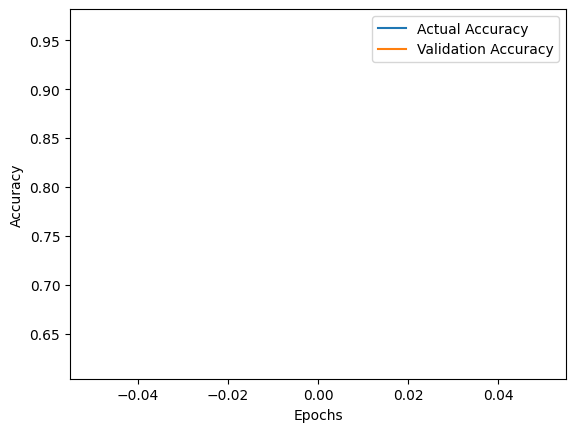

In [26]:
plt.plot(history.history['accuracy'], label='Actual Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel("Accuracy")

plt.legend()
plt.show()

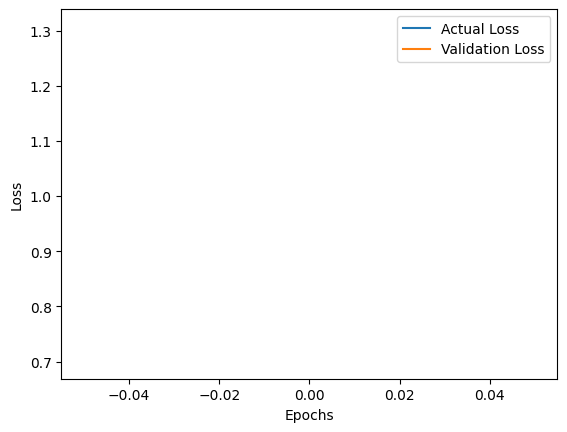

In [27]:
plt.plot(history.history['loss'], label="Actual Loss")
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel("Loss")

plt.legend()
plt.show()

## First Model Inferance

In [28]:
# ******************** inference for first model ******************
def predict_top3(model, X):
    # Get probabilities for all 5 classes
    probs= model.predict(X)
    # Get top 3 indices for each sample
    top3_indices= np.argsort(probs, axis=1)[:, -3:][:,::-1]

    # Convert back to A, B, C, D, E
    reverse_map_level= {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
    predictions=[]
    for indics in top3_indices:
        predictions.append([reverse_map_level[i] for i in indics])
    return predictions

## Evaluation

In [29]:
def calculate_map(predictions, ground_truth):
    """
    predictions would be [["A", "B", "D"],..] like this and 
    ground_truth would be ["A", "B", ...]
    """
    scores=[]
    for preds, truth in zip(predictions, ground_truth):
        if truth in preds:
            position= preds.index(truth)+ 1 # 1-indexed
            scores.append(1.0/position)
        else:
            scores.append(0.0)

    return np.mean(scores)

In [30]:
# ***** prediction on validation data and evaluation ****
# by model1
pred_top3_val_data= predict_top3(model, X_val)

model1_eval_score_on_val= calculate_map(pred_top3_val_data,val_data['answer'].tolist())

print(f"@map for first model:{model1_eval_score_on_val}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
@map for first model:0.9764150943396226


In [31]:
run_1.log({
    "@map_on_val":model1_eval_score_on_val
})

run_1.finish()

@map_on_val,▁
@map_on_val,0.97642


## Model 2 (Transfer Learning Strategies) 
* Treat each option separately as a classification task

In [34]:
############### weight and bais initiaze for second model ##############
# Start a new wandb run to track this script.
run_2 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Model2-Transfer Learning Strategy",
    config={
        "architecture": "distilbert",
        "epochs": 1,
        "batch_size": 16,
        "number of levels":2
    },
)

In [35]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset

# ******************** Choose pretrain model ****************
# Options (ranked by quality vs speed):
# 1. "distilbert-base-uncased" - FASTEST, good enough 
# 2. "bert-base-uncased" - BALANCED
# 3. "roberta-base" - BEST QUALITY, slower
# 4. "microsoft/deberta-base" - CUTTING EDGE (if GPU available)

model_name= "distilbert-base-uncased"
# model_name= "microsoft/deberta-base"

tokenizer= AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer loaded : {model_name}")
print(f"Vocab size : {tokenizer.vocab_size}")

# *********** step2: format data for bert ******************

def format_question_option(question, option):
    """
    fomat would be : [CLS] question [SEP] option [SEP]
    This helps BERT understand: question is premise, option is hypothesis
    """
    return f"{question} [SEP] {option}"

X_data=[]
y_data=[]

for _, row in train_data.iterrows():
    clear_ques= row['prompt'] # Already clear

    for option_letter in ['A', 'B', 'C', 'D', 'E']:
        option_text= row[option_letter]
        formatted= format_question_option(clear_ques,option_text)
        X_data.append(formatted)

        # Label: 1 if this option is correct, 0 otherwise
        label= 1 if row['answer']== option_letter else 0
        y_data.append(label)
print(f"Training egs created: {len(X_data)}")
# 1576(train size after splite) questions × 5 options = 10,000 training examples!

# ============ STEP 3: TOKENIZE ============
# BERT works with token IDs, not raw text

train_encodings= tokenizer(
    X_data, 
    truncation=True,
    padding= True,
    max_length=512, # max len of question + option
    return_tensors='pt', # pytorch tensors
)


print(f"Input Ids shape: {train_encodings['input_ids'].shape}")
print(f"Attension masked shape: {train_encodings['attention_mask'].shape}")

# convert label to tensor

y_data_tensor= torch.tensor(y_data)

# *************** step4: create dataset *********

class MCQDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings= encodings
        self.labels= labels

    def __getitem__(self, idx):
        item={
            "input_ids": self.encodings['input_ids'][idx],
            "attention_mask":self.encodings['attention_mask'][idx]
        }
        item['labels']= self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)
        

train_dataset= MCQDataset(train_encodings, y_data_tensor)
train_loader= DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Data loader created with batch size 16")



/home/aditya29f70/smart_mcq_solver_challenge_iitm_dl_genai_proj/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer loaded : distilbert-base-uncased
Vocab size : 30522
Training egs created: 7880
Input Ids shape: torch.Size([7880, 200])
Attension masked shape: torch.Size([7880, 200])
Data loader created with batch size 16


In [36]:
# ******************** step 5: load pretrained bert ******************
model_1= AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2, # binary: correct 1 or incorrect 0
)

# Get the underlying transformer model
base_model = model_1.base_model

# # Freeze all except last 2 layers
# for param in base_model.encoder.layer[:-2].parameters():
#     param.requires_grad = False

# Freeze first 4 layers (DistilBERT has 6 layers total)
for param in base_model.transformer.layer[:-2].parameters():
    param.requires_grad = False


device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_1.to(device)
print(f"\nModel loaded on device: {device}")


# **************** step6: fine-tune on our data ***************
from torch.optim import AdamW
optimizer= AdamW(model_1.parameters(), lr=2e-5) # transfer learning LR

num_epochs=1
model_1.train()
print(f"\nStarting fine-tuning for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    total_loss=0

    for batch_idx, batch in enumerate(train_loader):
        # Move batch to device
        input_ids= batch['input_ids'].to(device)
        attention_mask= batch['attention_mask'].to(device)
        labels= batch['labels'].to(device)

        # forward pass
        output= model_1(
            input_ids= input_ids,
            attention_mask= attention_mask,
            labels= labels
        )
        loss= output.loss

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+= loss.item()

        if (batch_idx+1)% 50==0:
            print(f"Epoch: {epoch+1}, Batch: {batch_idx}/{len(train_loader)}, Loss: {loss.item():0.4f}")
    avg_loss= total_loss/len(train_loader)
    print(f"Epoch: {epoch+1}, Average Loss: {avg_loss}")

print("Fine-tune completed!")
        
            


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3803.15it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded on device: cuda

Starting fine-tuning for 1 epochs...

Epoch: 1, Batch: 49/493, Loss: 0.4050
Epoch: 1, Batch: 99/493, Loss: 0.3086
Epoch: 1, Batch: 149/493, Loss: 0.4736
Epoch: 1, Batch: 199/493, Loss: 0.6882
Epoch: 1, Batch: 249/493, Loss: 0.4930
Epoch: 1, Batch: 299/493, Loss: 0.5266
Epoch: 1, Batch: 349/493, Loss: 0.5558
Epoch: 1, Batch: 399/493, Loss: 0.6216
Epoch: 1, Batch: 449/493, Loss: 0.3457
Epoch: 1, Average Loss: 0.49928774849396446
Fine-tune completed!


In [37]:
print(model_1)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [38]:
# ******************* step7 : prediction on validate ****************

def predict_with_bert_model2(model, val_data, tokenizer, device):
    """
    For each question, get scores for all 5 options
    Rank them to get top 3
    """
    model.eval()
    predictions=[]

    with torch.no_grad():
        prop=[]
        for _, row in val_data.iterrows():
            clear_q= row['prompt']

            # get score for all 5 options
            option_scores={}

            each_row_prob=[]
            for option in ['A', 'B', 'C', 'D', 'E']:
                option_text= row[option]
                formatted= format_question_option(clear_q, option_text)

                # Tokenize
                encoding = tokenizer(
                    formatted,
                    truncation=True,
                    padding=True,
                    max_length=512,
                    return_tensors='pt'
                )
                
                # Move to device
                input_ids= encoding['input_ids'].to(device)
                attention_mask= encoding['attention_mask'].to(device)

                # get logists
                outputs= model(input_ids=input_ids, attention_mask= attention_mask)
                logits= outputs.logits[0]

                # score= probability of being correct
                score= torch.softmax(logits, dim=0)[1].item() # class 1 = correct probability
                option_scores[option]= score
                each_row_prob.append(score)

            prop.append(each_row_prob)
            # sort by score, get top 3
            top3= sorted(option_scores.items(), key= lambda x: x[1], reverse=True)[:3]
            top3_letters= [letter for letter, score in top3]
            predictions.append(top3_letters)
    return predictions,prop
            
# Predict on validation
# print("Generating predictions on validation set...")

# val_predictions_model2= predict_with_bert_model2(
#     model_1, val_data, tokenizer, device
# )           
                
                

## Inferance model2

In [39]:
# ******************** inference for second model ******************
def predict_top3_2(model, val_data, tokenizer, device):
    top3_list,_= predict_with_bert_model2(model, val_data, tokenizer, device)
    top3= [" ".join(top3) for top3 in top3_list]
    return top3

In [40]:
pred_test_top3= predict_top3_2(model_1, test_df,tokenizer, device)

## Evaluation Model2

In [41]:
# by model2
pred_top3_val_data_sec_model= predict_top3_2(model_1, val_data,tokenizer, device)
model2_eval_on_val= calculate_map(pred_top3_val_data_sec_model,val_data['answer'].tolist())
print(f"@map for second model: {model2_eval_on_val}")

run_2.log({
    "@map_on_val":model2_eval_on_val
})

run_2.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


@map for second model: 0.7084905660377357


@map_on_val,▁
@map_on_val,0.70849


## Model 3 

In [42]:
############### weight and bais initiaze for third model ##############
# Start a new wandb run to track this script.
run_3 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Model3-Combine base model and transfer model results",
    config={
        "architecture": "ensemble_prediction",
    },
)

In [43]:
# Essemble or alternative model arch
# model1+ model2

f_model_pred= model.predict(X_test)
_,s_model_pred= predict_with_bert_model2(model_1, test_df,tokenizer, device)

def ensemble_prediction(pred1, pred2, weights=[0.3,0.7]):
    # Combine probability scores from both models
    # Weight pretrained model higher (usually better)
    ensemble_probs= weights[0]* pred1 + weights[1]* pred2

    # get top 3
    top3_indices= np.argsort(ensemble_probs,axis=1)[:,-3:][:,::-1]
    reverse_map_level= {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
    top3_letter_list=[]
    for indices in top3_indices:
        top3_letter_list.append([reverse_map_level[index] for index in indices])
    return [" ".join(top3_letter) for top3_letter in top3_letter_list]


model_3_result= ensemble_prediction(f_model_pred, np.array(s_model_pred))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


## Inferance Model3

In [44]:
# ***** prediction on validation data and evaluation ****

# by model3
f_model_pred_on_val= model.predict(X_val)
_,s_model_pred_on_val= predict_with_bert_model2(model_1, val_data,tokenizer, device)

model3_result_on_val= ensemble_prediction(f_model_pred_on_val, np.array(s_model_pred_on_val))

print(f"@map for third model: {calculate_map(model3_result_on_val,val_data['answer'].tolist())}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
@map for third model: 0.9632075471698113


## Evaluation

In [45]:
model3_eval_on_val= calculate_map(model3_result_on_val,val_data['answer'].tolist())
print(f"@map for third model: {model3_eval_on_val}")

@map for third model: 0.9632075471698113


In [46]:
run_3.log({
    "@map_on_val":model3_eval_on_val
})

run_3.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


@map_on_val,▁
@map_on_val,0.96321


## Model4 : Transfer Learning + GRU model

In [32]:
############### weight and bais initiaze for fourth model ##############
# Start a new wandb run to track this script.
run_4 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Transfer Learning+ GRU model",
    config={
        "architecture": "Transfer+GRU",
    },
)

In [33]:
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import pickle

In [ ]:
print("="* 70)
print("Model: TRANSFER LEARNING+GPU")
print('='*70)

# ************** step 1: data loader ****************
n_splits=1
splitter= GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

transfer_gru_results={
    'fold_models': [],
    'fold_scores': [],
    'fold_predictions': [],
    'tokenizer': None,
    'max_length': 200
}

# ************** step2 : PREPARE EMBEDDINGS ***************************
# Use pretrained GloVe embeddings (100-dim, faster than Word2Vec)
print("\nLoading pretrained GloVe embeddings...")

# Download from: https://nlp.stanford.edu/projects/glove/
# Or use gensim to download

from tensorflow.keras.layers import Embedding
import gensim.downloader as api


# Load pretrained word embeddings

try:
    word_vectors= api.load("glove-wiki-300") # 300-dimensional
    embedding_dim= 300
    print(f"Loaded GloVe-300 embeddings")
except:
    # fallback: smaller embedding
    print("Could not load GloVe, using random initialization")
    print("(Performance will be lower, but still good)")
    embedding_dim = 100

# ********************* Step 3: TOKENIZATION (Build on all training data) ***********************
# Combine question + options
all_texts= []
for _, row in train_data.iterrows():
    # combine question + options
    combined= f"{row['prompt']} {row['A']} {row['B']} {row['C']} {row['D']} {row['E']}"
    all_texts.append(combined)


# Create tokenizer
max_words= 10000 # Vocabulary size
tokenizer= Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(all_texts)

transfer_gru_results['tokenizer']= tokenizer
word_index= tokenizer.word_index
vocab_size= min(len(word_index)+1, max_words)

print("Tokenizer created: {vocab_size} words in vocabulary")

# ============ STEP 4: CREATE EMBEDDING MATRIX (Transfer Learning) ============
# Map word indices to pretrained embeddings

def create_embedding_matrix(word_index, word_vectors, embedding_dim):
    """
    Create embedding matrix using pretrained vectors
    Words not in pretrained set: random initialization
    """
    embedding_matrix= np.random.normal(
        loc=0,
        scale=0.5,
        size= (len(word_index)+1, embedding_dim)
    )

    oov_count=0
    found_count=0

    for word, idx in word_index.item():
        if idx>len(embedding_matrix):
            continue
        
        try:
            # Try to get pretrained vector
            embedding_vector= word_vectors[word]
            embedding_matrix[idx]= embedding_vector
            found_count+=1
        except KeyError:
            # word not in pretrained set
            oov_count+=1

    print(f"Found {found_count} pretrained embeddings")
    print(f"OOV (random init) {oov_count} words")

    return  embedding_matrix

try:
    embedding_matrix= create_embedding_matrix(word_index, word_vectors, embedding_dim)
    use_pretrained=True 
    print(f"Embedding matrix created: {embedding_matrix.shape}")
except:
    use_pretrained=False 
    embedding_dim=100
    print(f"Using random embeddings (not pretrained)")
    embedding_matrix = None

# ******************** Step5: Prepare data for neural network *****************

def prepare_text_for_gpu(row, tokenizer, max_length=300):
    """
    Convert question+ options into sequences
    Format: question [SEP] option
    """
    combined= f"{row['prompt']} [SEP] {row['A']} [SEP] {row['B']} [SEP] {row['C']} [SEP] {row['D']} [SEP] {row['E']}"

    # Tokenize
    sequences= tokenizer.texts_to_sequences([combined])

    # Pad to fixed length
    padded= pad_sequences(sequences, maxlen=max_length, padding='post')[0]
    return padded

max_length= 300
transfer_gru_results['max_length']= max_length

# ********* step6: build gru model ******************

def create_transfer_gru_model(embedding_matrix, vocab_size, embedding_dim, max_length):
    """
    Transfer Learning + GRU architecture
    
    Why GRU over LSTM?
    - Fewer parameters (3 gates vs 4)
    - Faster training
    - Less overfitting risk with small dataset
    - Similar performance for most tasks
    """

    model= keras.Sequential([
        # ========== EMBEDDING LAYER (Pretrained) ==========
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix] if embedding_matrix is not None else None,
            input_length=max_length,
            trainable=False,
            name="embedding"
        ),
        # ========== SPATIAL DROPOUT ==========
        # Drops entire feature maps (better than standard dropout for sequences)
        SpatialDropout1D(0.2),

        # ========== BIDIRECTIONAL GRU ==========
        # Process sequence forwards AND backwards for better context
        Bidirectional(
            GRU(
                units=128,
                return_sequences=True, # keep full sequence
                dropout= 0.2,
                recurrent_dropout=0.2
            ),
            name='bigru_1'
        ),
        # ========== SECOND GRU LAYER ==========
        # Stack another GRU for more expressive power
        Bidirectional(
            GRU(
                units=64,
                return_sequences=False, # return only last output
                dropout=0.2,
                recurrent_dropout=0.2
            ),
            name='bigru_2'
        ),

        # **************** Desne Layers *********************
        Dense(64, activation='relu', name='dense_1'),
        Dropout(0.3),

        Dense(32, activation='relu', name='dense_2'),
        Dropout(0.2),

        # ************** Output Layer ******************
        Dense(5, activation='softmax', name='output') # 5 classes A-E
    ])

    model.compile(
        optimizer= keras.optimizers.Adam(learning_rate= 0.001),
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy']
    )

    return model

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70 + "\n")


#************** step7: Cross-validation loop *******************

for fold, (train_idx, val_idx) in enumerate(splitter.split(train_df, groups=train_df['prompt_group']), 1):
    print(f"\n{'='*70}")
    print(f"Fold {fold}/{n_splits}")
    print(f"{'='*70}\n")

    # splite data
    train_data_4= train_df.iloc[train_idx].reset_index(drop=True)
    val_data_4= train_df.iloc[val_idx].reset_index(drop=True)

    print(f"Train: {len(train_data_4)} | Val: {len(val_data_4)}")

    # verify no leakage 
    overlap= set(train_data_4['prompt']) & set(val_data_4['prompt'])
    assert len(overlap) ==0

    # ************* prepare sequences ***************
    X_train= np.array([
        prepare_text_for_gpu(row, tokenizer, max_length) for _, row in train_data_4.iterrows()  
    ])

    X_val= np.array([
        prepare_text_for_gpu(row, tokenizer, max_length) for _, row in val_data_4.iterrows()
    ])

    print(f"input shape: {X_train.shape}")
    print(f"sequence length: {max_length}")
    print(f"vocab size: {vocab_size}")

    # *********** build model ********************
    print("Building Transfer Learning + GRU model...")
    model_4= create_transfer_gru_model(
        embedding_matrix if use_pretrained else None,
        vocab_size,
        embedding_dim,
        max_length
    )

    print(model_4.summary())

    # ************** Train ********************
    print(f"\n Training Fold {fold}...\n")

    early_stopping= keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history= model_4.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=1
    )

Model: TRANSFER LEARNING+GPU

Loading pretrained GloVe embeddings...
Could not load GloVe, using random initialization
(Performance will be lower, but still good)
Tokenizer created: {vocab_size} words in vocabulary
Using random embeddings (not pretrained)

MODEL ARCHITECTURE


Fold 1/1

Train: 1576 | Val: 424
input shape: (1576, 300)
sequence length: 300
vocab size: 3014
Building Transfer Learning + GRU model...


/home/aditya29f70/smart_mcq_solver_challenge_iitm_dl_genai_proj/venv/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_1 (Bidirectional)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_2 (Bidirectional)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

 Training Fold 1...

Epoch 1/500
28/99 ━━━━━━━━━━━━━━━━━━━━ 23s 336ms/step - accuracy: 0.1735 - loss: 1.6091

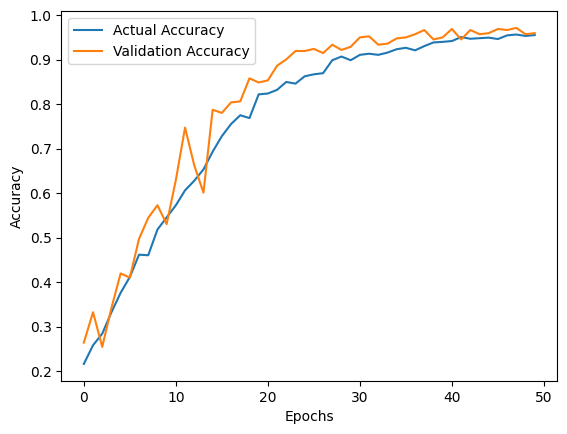

In [42]:
plt.plot(history.history['accuracy'], label='Actual Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel("Accuracy")

plt.legend()
plt.show()

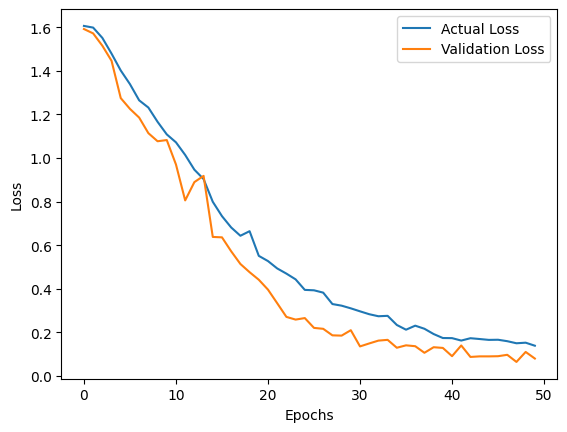

In [43]:
plt.plot(history.history['loss'], label="Actual Loss")
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel("Loss")

plt.legend()
plt.show()

## Model 4 evaluation

In [44]:
# ******************* Evaluate ***************************
print(f"\n Evaluating....")

val_probs = model_4.predict(X_val, verbose=0)

# Convert to top 3 predictions
label_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}

top3_indices = np.argsort(val_probs, axis=1)[:, -3:][:, ::-1]

val_predictions = []
for indices in top3_indices:
    val_predictions.append([label_to_letter[i] for i in indices])


map3_score = calculate_map(val_predictions, val_data['answer'].tolist())

print(f"\n Transfer Learning + GRU MAP@3: {map3_score:.4f}\n")


# Store results
transfer_gru_results['fold_models'].append(model)
transfer_gru_results['fold_scores'].append(map3_score)
transfer_gru_results['fold_predictions'].append(val_predictions)



 Evaluating....

 Transfer Learning + GRU MAP@3: 0.9858



In [45]:
run_4.log({
    "@map_on_val":map3_score
})

run_4.finish()

@map_on_val,▁
@map_on_val,0.98585


## Submission

In [48]:
# ************ for model 4 ************************
X_test= np.array([
    prepare_text_for_gpu(row, tokenizer, max_length) for _, row in test_df.iterrows()
])

test_props = model_4.predict(X_test, verbose=0)

# Convert to top 3 predictions
label_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}

top3_indices = np.argsort(test_props, axis=1)[:, -3:][:, ::-1]

val_predictions = []
for indices in top3_indices:
    val_predictions.append([label_to_letter[i] for i in indices])

model_4_pred_on_test= [" ".join(lst_idx) for lst_idx in val_predictions]

In [50]:
# model_3_result

submission_df= pd.DataFrame({
    "id": test_df['id'],
    "prediction":  model_4_pred_on_test
})

In [51]:
submission_df.to_csv("submission.csv", index=False)

In [49]:
print(f"@map for first model:{calculate_map(pred_top3_val_data,val_data['answer'].tolist())}")
print(f"@map for second model: {calculate_map(pred_top3_val_data_sec_model,val_data['answer'].tolist())}")
print(f"@map for third model: {calculate_map(model3_result_on_val,val_data['answer'].tolist())}")

@map for first model:0.9602987421383649
@map for second model: 0.7084905660377357
@map for third model: 0.9632075471698113


In [50]:
# calculate_map(val_predictions_model2, val_data['answer'].tolist())